Nama : Dzhahira Shafa

NIM : 09011382227150

Kelas : SKU7

# UTS DEEP LEARNING
Membangun dan mengevaluasi data diabetes dengan Convolutional Neural Network (CNN)

Tujuan:




*   Melakukan pra-pemrosesan data (handling missing value, normalisasi, encoding).
*   Membentuk ulang data tabular menjadi representasi 2D agar bisa diproses CNN.
*   Membangun model CNN dengan 3 convolutional layers.
*   Mengevaluasi performa CNN menggunakan confusion matrix & classification report.


Menggunakan **Dataset Predict Online Gaming Behavior** dari **Kaggle**.

https://www.kaggle.com/datasets/rabieelkharoua/predict-online-gaming-behavior-dataset?resource=download





# Input library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Dataset dibaca dengan pandas

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Baca dataset langsung dari Drive
path = "/content/drive/MyDrive/UTS DEEP LEARNING/online_gaming_behavior_dataset.csv"
df = pd.read_csv(path)

# Tampilkan data
display(df.head())
print("Ukuran data:", df.shape)

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


Ukuran data: (40034, 13)


In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (40034, 13)


**Dataset mempunyai 40034 baris dan 13 kolom**

# Pra-premrosesan Data

## Missing Value



In [ ]:
print(df.isnull().sum())

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64


hasil pengecekan menunjukkan dataset tidak memiliki **missing value.**

## Encoding fitur dan label

In [ ]:
for col in ['Gender', 'Location', 'GameGenre', 'GameDifficulty']:
    df[col] = LabelEncoder().fit_transform(df[col])

kode ini digunakan untuk mengubah kolom **fitur kategorikal** seperti Gender, Location, GameGenre, dan GameDifficulty menjadi nilai numerik agar bisa diproses oleh model. Yang merupakan **fitur** **(X)**, bukan target.

In [ ]:
X = df.drop("EngagementLevel", axis=1).values
y = df["EngagementLevel"].values

In [ ]:
from tensorflow.keras.utils import to_categorical

# Misal y adalah kolom EngagementLevel (Low / Medium / High)
le_target = LabelEncoder()
y_enc = le_target.fit_transform(y)
y_cat = to_categorical(y_enc, num_classes=3)


print("Kelas target:", le_target.classes_)  # ['High', 'Low', 'Medium'] atau urutan semacam itu
print("Distribusi:\n ", pd.Series(y_enc).value_counts())


Kelas target: ['High' 'Low' 'Medium']
Distribusi:
  2    19374
0    10336
1    10324
Name: count, dtype: int64


Kode diatas digunakan untuk **mengubah kolom target (y)** yaitu EngagementLevel menjadi format numerik dan selanjutnya menjadi one-hot encoding (misalnya [1,0,0] untuk “Low”, [0,1,0] untuk “Medium”, dll).
Ini diperlukan karena model CNN dengan **softmax** output membutuhkan target dalam format one-hot.

## Membentuk ulang data tabular menjadi representasi 2D


In [ ]:
import math
from math import ceil, sqrt

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Scale the data and assign to X_scaled

n_samples, n_features = X_scaled.shape

# cari ukuran matriks persegi terdekat
size = ceil(sqrt(n_features))        # contoh: 13 → 4
pad = size**2 - n_features           # jumlah kolom nol yang perlu ditambah

# tambahkan kolom nol agar bisa reshape ke matriks persegi
X_pad = np.hstack([X_scaled, np.zeros((n_samples, pad))])

# ubah ke bentuk 2D untuk CNN (dengan channel 1)
X_2d = X_pad.reshape(n_samples, size, size, 1)

print(f"\nReshape ke 2D: dari {n_features} fitur → {size}x{size}")
print("Shape akhir:", X_2d.shape)


Reshape ke 2D: dari 12 fitur → 4x4
Shape akhir: (40034, 4, 4, 1)


Kode di atas digunakan untuk mengubah data tabular (fitur numerik) menjadi bentuk dua dimensi (**2D**) agar dapat diproses oleh Convolutional Neural Network (CNN).

Pertama, program menghitung jumlah fitur dari dataset, lalu mencari ukuran matriks persegi terdekat menggunakan fungsi **ceil**(sqrt(n_features)). Misalnya, jika terdapat 13 fitur, maka ukuran persegi yang paling dekat adalah 4×4 (karena 4² = 16).

Selanjutnya, kode menambahkan **padding** (nilai nol) sebanyak yang diperlukan agar jumlah total fitur bisa membentuk persegi sempurna. Proses ini dilakukan dengan np.hstack, yang menambahkan kolom nol ke data asli.

Setelah itu, data diubah ke format 4D menggunakan reshape(n_samples, size, size, 1), di mana:

n_samples = jumlah sampel,


size × size = ukuran matriks (misalnya 4×4),

1 = jumlah channel (karena datanya grayscale / satu saluran).


# Spliting Data


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y_cat, test_size=0.3, random_state=42, stratify=y_enc
)
print("\nTrain shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (28023, 4, 4, 1) | Test shape: (12011, 4, 4, 1)


Pada bagian ini, data dibagi menjadi dua bagian yaitu data latih dan data uji menggunakan fungsi train_test_split. Sebanyak **70%** data digunakan untuk melatih model dan **30%** sisanya digunakan untuk pengujian.

# Perancangan dan Pembangunan Model CNN

In [ ]:
# 🔧 Model CNN untuk data tabular 4x4x1
def build_model(input_shape=(4,4,1), num_classes=3):
    model = Sequential([
        # Layer 1: Conv + BN
        Conv2D(32, (2,2), activation="relu", padding="same", input_shape=input_shape),
        BatchNormalization(),

        # Layer 2: Conv + MaxPool
        Conv2D(64, (2,2), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        # Layer 3: Conv terakhir
        Conv2D(128, (2,2), activation="relu", padding="same"),
        BatchNormalization(),
        Flatten(),
        Dropout(0.3),

        # Dense layer
        Dense(64, activation="relu"),
        Dropout(0.4),

        # Output layer (3 kelas)
        Dense(num_classes, activation="softmax")
    ])

    # Kompilasi model
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Inisialisasi dan tampilkan arsitektur model
model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 4, 4, 32)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 4, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 64)       │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 128)      │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,235 (293.89 KB)

 Trainable params: 74,787 (292.14 KB)

 Non-trainable params: 448 (1.75 KB)

CNN dipilih karena mampu menangkap hubungan antar fitur dalam bentuk matriks 2D, berbeda dari model tabular tradisional seperti **MLP (Multilayer Perceptron)**.
Secara keseluruhan, arsitektur CNN yang dibangun terdiri dari tiga lapisan konvolusi utama dengan kombinasi Batch **Normalization**, **Pooling**, dan **Dropout** yang berfungsi untuk meningkatkan kestabilan, efisiensi, dan kemampuan generalisasi model.


*   Layer konvolusi pertama menggunakan 32 filter ukuran 2×2 dan aktivasi ReLU. Pemilihan kernel 2×2 dan padding="same" didasari oleh ukuran input kecil (4×4): kernel kecil lebih masuk akal untuk menangkap pola lokal antar fitur tanpa membuat output terlalu kecil. ReLU dipilih karena sederhana, cepat, dan efektif mengatasi vanishing gradient pada jaringan dalam.
*   Layer konvolusi kedua menggandakan jumlah filter menjadi 64 agar model dapat mempelajari pola yang lebih banyak/kompleks. Pola umum dalam desain CNN adalah meningkatkan jumlah filter pada lapisan lebih dalam untuk menangkap fitur berlevel lebih tinggi.

*   Lapisan konvolusi ketiga menambah kapasitas model lagi untuk menangkap fitur yang lebih tinggi; diikuti BatchNormalization untuk stabilitas, Flatten untuk mengubah feature map 2D menjadi vektor 1D, dan Dropout(0.3) sebagai regularisasi tambahan.
*   **Dense(num_classes, activation="softmax")** adalah layer output yang menghasilkan probabilitas untuk tiap kelas (3 neuron → 3 kelas). softmax dipilih karena ini kasus multiclass.
*   **Adam** dipilih sebagai optimizer karena adaptif (menyesuaikan learning rate per parameter) dan umumnya bekerja baik tanpa banyak tuning. **Categorical crossentropy** cocok digunakan karena target memiliki tiga kelas (multiclass classification).






Model ini dirancang untuk mendeteksi pola kompleks antar fitur yang telah direpresentasikan dalam bentuk matriks 2D. Dengan adanya lapisan-lapisan ini, CNN diharapkan mampu menghasilkan akurasi yang baik dalam mengklasifikasikan tingkat Engagement Level pengguna (Low, Medium, dan High).

# Model Training dan Evaluasi

## Training Data

In [ ]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping, model_checkpoint])

Epoch 1/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.6865 - loss: 0.8092 - val_accuracy: 0.8444 - val_loss: 0.4430
Epoch 2/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8486 - loss: 0.4905 - val_accuracy: 0.9015 - val_loss: 0.3646
Epoch 3/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8708 - loss: 0.4429 - val_accuracy: 0.8724 - val_loss: 0.4041
Epoch 4/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8766 - loss: 0.4298 - val_accuracy: 0.9037 - val_loss: 0.3550
Epoch 5/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8837 - loss: 0.4190 - val_accuracy: 0.8990 - val_loss: 0.3603
Epoch 6/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8868 - loss: 0.4057 - val_accuracy: 0.9142 - val_loss: 0.3409
Epoch 7/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8923 - loss: 0.3931 - val_accuracy: 0.9153 - val_loss: 0.3379
Epoch 8/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8912 - loss: 0.3977 - val_a

Pada tahap pelatihan model, digunakan dua callback, yaitu **EarlyStopping** dan **ModelCheckpoint**.
**EarlyStopping** berfungsi untuk menghentikan proses pelatihan secara otomatis apabila nilai validation loss tidak mengalami perbaikan selama 10 epoch, guna mencegah overfitting.
Sementara itu, **ModelCheckpoint** digunakan untuk menyimpan bobot model terbaik berdasarkan nilai validation loss terendah dalam file best_model.keras.
Model kemudian dilatih menggunakan data latih (X_train, y_train) selama maksimal 100 epoch dengan batch size 32, serta pembagian data validasi sebesar 20% dari data latih.

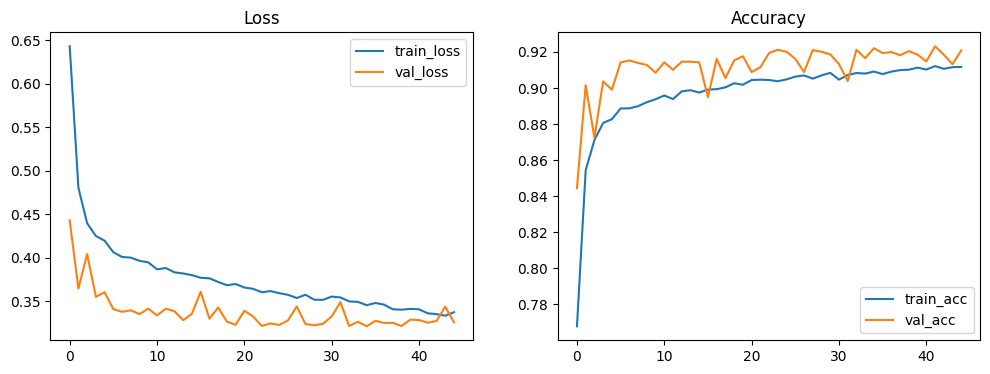

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend(); plt.title("Accuracy")
plt.show()

Kode ini digunakan untuk **menampilkan grafik hasil pelatihan model CNN**, yaitu **perbandingan antara nilai *loss* dan *accuracy*** pada data latih dan data validasi selama proses pelatihan.

* Grafik **Loss** (kiri) menunjukkan bahwa nilai *train loss* dan *validation loss* menurun seiring bertambahnya *epoch*, menandakan model semakin baik dalam meminimalkan kesalahan prediksi.
* Grafik **Accuracy** (kanan) memperlihatkan bahwa *train accuracy* dan *validation accuracy* meningkat dan stabil di atas **90%**, menandakan model berhasil melakukan pembelajaran dengan baik tanpa gejala *overfitting* yang signifikan.


## Model Evaluasi

Test Loss: 0.3419
Test Accuracy: 0.9132
376/376 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
F1-score: 0.9129

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      3101
           1       0.91      0.88      0.89      3097
           2       0.91      0.94      0.93      5813

    accuracy                           0.91     12011
   macro avg       0.91      0.90      0.91     12011
weighted avg       0.91      0.91      0.91     12011


Confusion Matrix:


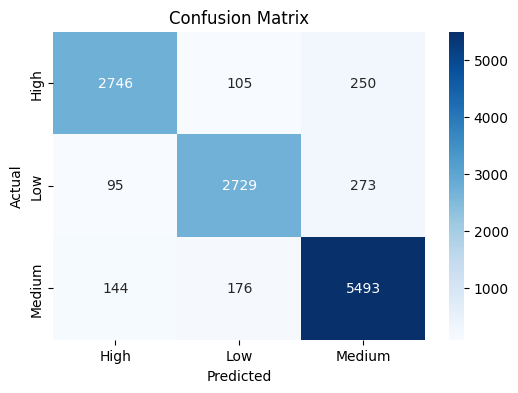

In [ ]:

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
# Get predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert y_test back to integer labels for evaluation
y_test_int = np.argmax(y_test, axis=1)

f1 = f1_score(y_test_int, y_pred, average='weighted')
print(f"F1-score: {f1:.4f}")

# Display classification report and confusion matrix
print("\nClassification Report:")
print(classification_report(y_test_int, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_int, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Hasil evaluasi model menunjukkan bahwa **CNN mampu memprediksi tingkat keterlibatan pemain (High, Low, Medium) dengan akurasi tinggi**, yaitu **91,32%** dan nilai **F1-score sebesar 0,9129**.

Dari **classification report**, setiap kelas memiliki nilai **precision**, **recall**, dan **F1-score** sekitar 0,89–0,94, yang berarti model memiliki keseimbangan baik antara ketepatan dan kemampuan mendeteksi tiap kelas.

Sementara itu, **confusion matrix** memperlihatkan sebagian besar data berhasil diklasifikasikan dengan benar di diagonal utama, menandakan performa model yang stabil dan konsisten dalam mengenali pola dari ketiga kelas target.


# Model pembanding CNN dengan ML (RandoForest)

Menggunakan randomforest sebagai pembanding karena model ini kuat, mudah digunakan, dan sering jadi baseline di data tabular.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10
)
rf_model.fit(X_train.reshape(X_train.shape[0], -1), y_train.argmax(axis=1))  # ubah kembali ke bentuk 2D

# Prediksi
y_pred_rf = rf_model.predict(X_test.reshape(X_test.shape[0], -1))

In [ ]:
# Evaluasi
acc_rf = accuracy_score(y_test.argmax(axis=1), y_pred_rf)
print(f"Akurasi Random Forest: {acc_rf:.4f}")
f1 = f1_score(y_test_int, y_pred, average='weighted')
print(f"F1-score: {f1:.4f}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_test.argmax(axis=1), y_pred_rf, target_names=le_target.classes_))

Akurasi Random Forest: 0.8802
F1-score: 0.9129

Classification Report (Random Forest):
              precision    recall  f1-score   support

        High       0.91      0.80      0.85      3101
         Low       0.91      0.83      0.87      3097
      Medium       0.85      0.95      0.90      5813

    accuracy                           0.88     12011
   macro avg       0.89      0.86      0.87     12011
weighted avg       0.88      0.88      0.88     12011



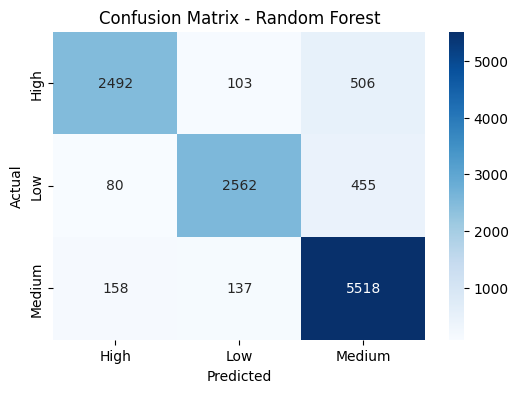

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test.argmax(axis=1), y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

## Kesimpulan

Berdasarkan hasil penelitian pada dataset *Predict Online Gaming Behavior*, model **CNN** memberikan performa terbaik dengan akurasi **0.9132** dan F1-score **0.9129**, sedikit lebih tinggi dibandingkan **Random Forest** yang memiliki akurasi **0.8802** dan F1-score **0.9129**. Hal ini menunjukkan bahwa CNN lebih unggul dalam mengenali pola kompleks antar fitur, sementara Random Forest tetap memberikan hasil yang baik untuk data tabular.

Kelebihan model CNN terletak pada kemampuannya menangkap hubungan non-linier antar variabel, meskipun membutuhkan waktu pelatihan dan sumber daya komputasi yang lebih besar. Sementara itu, Random Forest memiliki keunggulan pada kemudahan interpretasi dan efisiensi pelatihan, namun kurang optimal dalam mempelajari pola yang sangat kompleks. Secara keseluruhan, CNN memberikan hasil yang lebih unggul, tetapi pemilihan model tetap perlu disesuaikan dengan tujuan, kompleksitas data, dan ketersediaan sumber daya komputasi.
